# ✈️ Airline Customer Satisfaction Prediction
### Logistic Regression | Binary Classification
---

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load & Explore the Dataset

In [7]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [8]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64


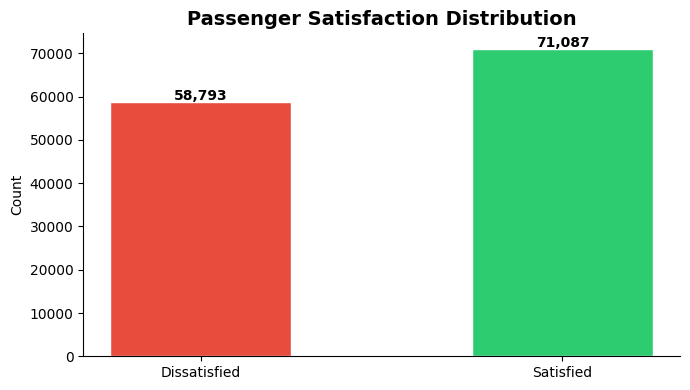

In [9]:
# Class distribution
print(df['satisfaction'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
counts = df['satisfaction'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax.bar(['Dissatisfied', 'Satisfied'], [counts['dissatisfied'], counts['satisfied']],
       color=colors, edgecolor='white', width=0.5)
ax.set_title('Passenger Satisfaction Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([counts['dissatisfied'], counts['satisfied']]):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 3. Data Cleaning & Preprocessing

In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


In [11]:
# Handle missing values (Arrival Delay has 393 nulls)
df.fillna(df.median(numeric_only=True), inplace=True)
df.dropna(inplace=True)

# Drop irrelevant ID columns if present
df.drop(columns=['ID', 'Unnamed: 0'], inplace=True, errors='ignore')

print(f"Clean dataset shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Clean dataset shape: (129880, 22)
Remaining nulls: 0


## 4. Label Encoding
Convert categorical text columns into numeric values for the model.

In [12]:
encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("\nEncoding complete. Sample encoded values:")
df.head()

Categorical columns: ['satisfaction', 'Customer Type', 'Type of Travel', 'Class']

Encoding complete. Sample encoded values:


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,0,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,0,47,1,0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,0,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,0,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,0,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## 5. Train-Test Split

In [13]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 103,904 samples
Test set:     25,976 samples


## 6. Feature Scaling
Standardize features so coefficients are comparable and model converges.

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling applied.")

Scaling applied.


## 7. Train Logistic Regression Model

In [15]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)
print("Model trained successfully.")
print(model)

Model trained successfully.
LogisticRegression(max_iter=1000, random_state=42)


## 8. Model Evaluation

In [16]:
y_pred = model.predict(X_test_sc)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print("=" * 40)

  Accuracy  : 0.8258  (82.58%)
  Precision : 0.8424  (84.24%)
  Recall    : 0.8409  (84.09%)


### 8a. Confusion Matrix

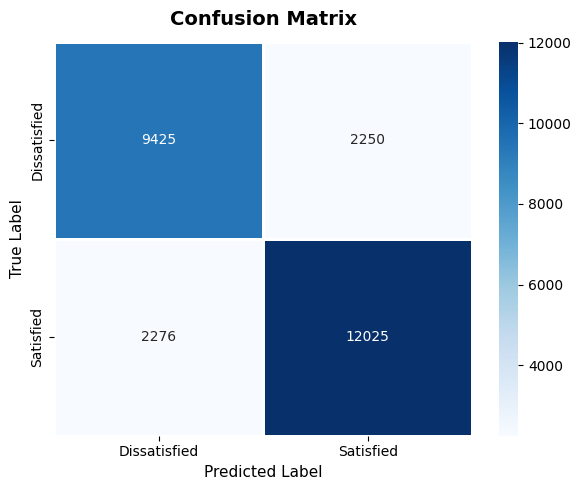

True Negatives  (correctly predicted Dissatisfied): 9,425
False Positives (wrongly predicted Satisfied):      2,250
False Negatives (missed Satisfied passengers):      2,276
True Positives  (correctly predicted Satisfied):    12,025


In [17]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'],
            linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"True Negatives  (correctly predicted Dissatisfied): {TN:,}")
print(f"False Positives (wrongly predicted Satisfied):      {FP:,}")
print(f"False Negatives (missed Satisfied passengers):      {FN:,}")
print(f"True Positives  (correctly predicted Satisfied):    {TP:,}")

### 8b. Classification Report

In [18]:
print(classification_report(y_test, y_pred,
    target_names=['Dissatisfied (0)', 'Satisfied (1)']))

                  precision    recall  f1-score   support

Dissatisfied (0)       0.81      0.81      0.81     11675
   Satisfied (1)       0.84      0.84      0.84     14301

        accuracy                           0.83     25976
       macro avg       0.82      0.82      0.82     25976
    weighted avg       0.83      0.83      0.83     25976



## 9. Feature Coefficients & Interpretation

Each coefficient represents the change in **log-odds** of satisfaction for a 1-unit increase in that feature (after scaling). Positive = increases satisfaction; Negative = decreases it.

In [19]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

                          Feature  Coefficient
           Inflight entertainment     0.984318
                 On-board service     0.405525
                     Seat comfort     0.391341
                  Checkin service     0.360084
           Ease of Online booking     0.310413
                 Leg room service     0.305734
                  Online boarding     0.185504
                    Gate location     0.174666
                   Online support     0.142962
                 Baggage handling     0.114286
       Departure Delay in Minutes     0.079608
                      Cleanliness     0.075713
            Inflight wifi service    -0.116871
                              Age    -0.133186
                  Flight Distance    -0.180686
         Arrival Delay in Minutes    -0.269010
                            Class    -0.298191
                   Food and drink    -0.303581
Departure/Arrival time convenient    -0.340923
                   Type of Travel    -0.419212
             

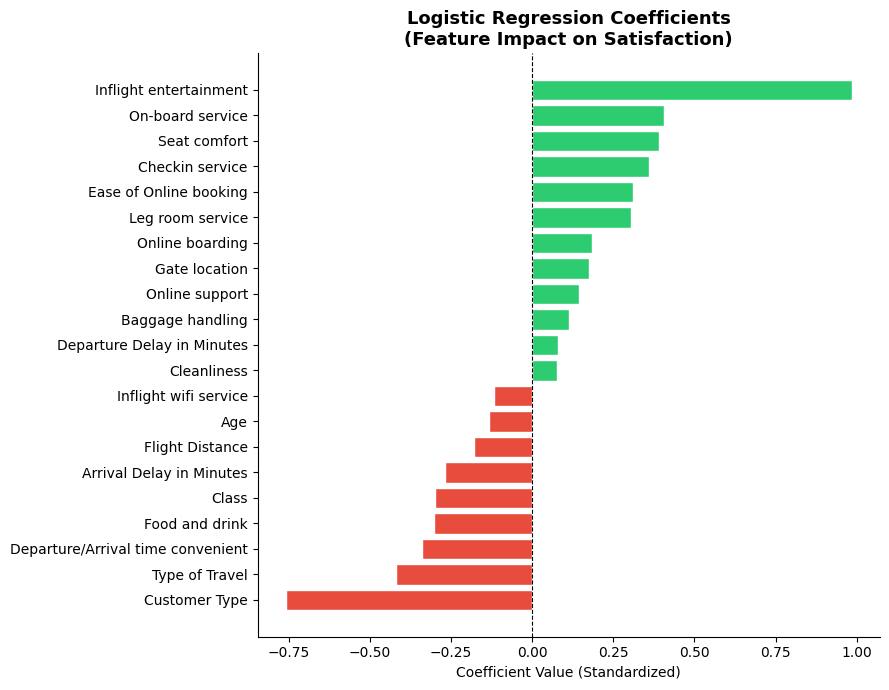

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(Feature Impact on Satisfaction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value (Standardized)')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

## 10. Business Insights

| # | Feature | Coefficient | Interpretation |
|---|---------|------------|----------------|
| 1 | Inflight Entertainment | +0.984 | Strongest driver of satisfaction. A 1-unit increase in rating raises log-odds by 0.98 |
| 2 | On-board Service | +0.406 | High-quality cabin crew significantly improves experience |
| 3 | Seat Comfort | +0.391 | Comfortable seats are a key satisfaction lever |
| 4 | Check-in Service | +0.360 | Smooth, friendly check-in sets a positive tone for the journey |
| 5 | Ease of Online Booking | +0.310 | Frictionless digital booking increases overall satisfaction |
| 6 | Customer Type | -0.759 | Disloyal customers are significantly less likely to be satisfied |
| 7 | Arrival Delay | -0.269 | Each unit increase in delay meaningfully reduces satisfaction |

### Actionable Recommendations
1. **🎬 Prioritise In-flight Entertainment** — the single biggest predictor (coef = +0.984). Upgrade content libraries and screen quality.
2. **🛋️ Invest in Seat Comfort** — especially in Economy/Eco Plus classes where satisfaction is lowest.
3. **📱 Improve Online Boarding & Booking UX** — digital friction reduces satisfaction even before passengers board.
4. **⏱️ Reduce Arrival Delays** — negative coefficient (−0.269) means delays directly erode satisfaction.
5. **🎁 Target Disloyal Customers** — the strongest negative driver (−0.759); loyalty programmes and personalised offers can convert them.

## 11. Limitations & Future Work
- Logistic Regression assumes linearity in log-odds; non-linear models (Random Forest, XGBoost) may perform better.
- Survey-based ratings carry inherent subjectivity/response bias.
- Model evaluated on single 80/20 split; k-fold cross-validation would give a more robust estimate.
- Future: explore ensemble methods, SHAP values for explainability, and deploy model via a REST API.
